# Negotiation Arena: Human and LLM Negotiation Dynamics

## Experimental Design
The analysis framework explores negotiation dynamics across three distinct dimensions:
1. **Human Baseline Evaluation**: Statistical and structural profiling of dialogue acts and issue distributions in `Negochat`.
2. **Human-Seeded Continuity**: Evaluating the capacity of LLMs to sustain a realistic human cooperative trajectory.
3. **Evaluation & Strategic Sensitivity**: Analyzing how environmental rules (Explicit vs. Compatibility) and private utility thresholds shift negotiation success.

In [24]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global Academic Theme Setup
sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.titlesize"] = 14

from src.data_loader import load_or_create_human_data
from src.visualization import plot_transition_heatmap
from src.metrics import infer_human_outcome, infer_human_outcome_refined, compute_transition_matrix

## DATA LOADING

In [25]:
human_df = load_or_create_human_data(
    raw_path="../data/raw/negochat",
    processed_path="../data/processed/human_negotiations.csv"
)

seeded_turns = pd.read_csv("../results/human_seeded_llm_turns_sample.csv")
seeded_outcomes = pd.read_csv("../results/human_seeded_llm_outcomes_sample.csv")
utility_turns = pd.read_csv("../results/utility_llm_turns_llama3.csv")
utility_outcomes = pd.read_csv("../results/utility_llm_outcomes_llama3.csv")

# Data profile summary table
data_profile = pd.DataFrame({
    "Dataset Layer": ["Human Baseline", "Human-Seeded LLM Turns", "Human-Seeded Outcomes", "Utility LLM Turns", "Utility LLM Outcomes"],
    "Rows / Shape": [human_df.shape[0], seeded_turns.shape[0], seeded_outcomes.shape[0], utility_turns.shape[0], utility_outcomes.shape[0]]
})
data_profile.style.hide(axis="index").background_gradient(cmap="Purples")

Dataset Layer,Rows / Shape
Human Baseline,4993
Human-Seeded LLM Turns,360
Human-Seeded Outcomes,20
Utility LLM Turns,145
Utility LLM Outcomes,27


## Human Baseline
### Dialogue Act Distribution

C:\Users\simon\AppData\Local\Temp\ipykernel_21468\2978041105.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=human_act_counts, x="Dialogue Act", y="Count", ax=ax, palette="viridis")


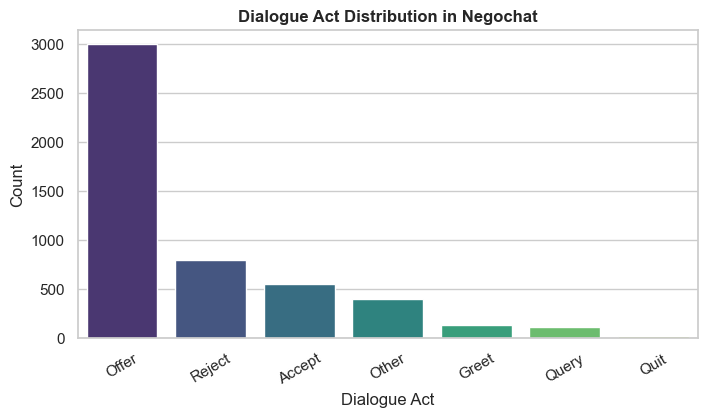

Dialogue Act,Count
Offer,2996
Reject,790
Accept,547
Other,394
Greet,135
Query,113
Quit,18


In [26]:
human_act_counts = human_df["act"].value_counts().to_frame().reset_index()
human_act_counts.columns = ["Dialogue Act", "Count"]


fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=human_act_counts, x="Dialogue Act", y="Count", ax=ax, palette="viridis")
ax.set_title("Dialogue Act Distribution in Negochat", weight="bold")
plt.xticks(rotation=30)
plt.show()

human_act_counts.style.hide(axis="index").background_gradient(cmap="Blues", subset=["Count"])

### Dialogue Act Transition Matrix

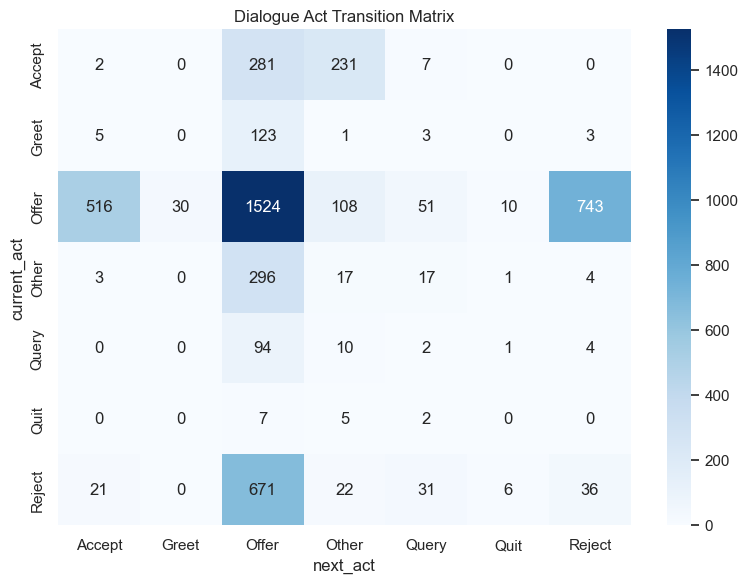

In [27]:
human_transition_matrix = compute_transition_matrix(human_df, act_col="act")
plot_transition_heatmap(human_transition_matrix)

### Negotiated Issues

C:\Users\simon\AppData\Local\Temp\ipykernel_21468\2281032887.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=human_issue_counts, y="Contract Dimension", x="Frequency", ax=ax, palette="rocket")


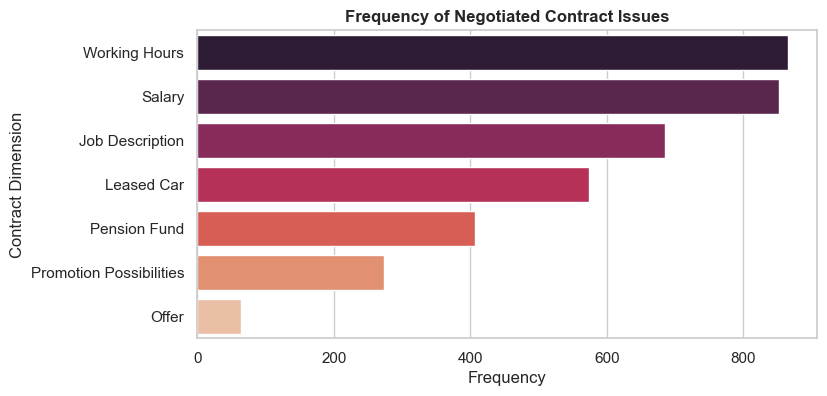

In [28]:
human_issue_counts = human_df["issue"].value_counts().to_frame().reset_index()
human_issue_counts.columns = ["Contract Dimension", "Frequency"]

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=human_issue_counts, y="Contract Dimension", x="Frequency", ax=ax, palette="rocket")
ax.set_title("Frequency of Negotiated Contract Issues", weight="bold")
plt.show()

### Human Dataset Outcomes: Simple vs. Refined Heuristic

In [29]:
human_outcomes = human_df.groupby("dialogue_id").apply(
    lambda g: pd.Series({"outcome": infer_human_outcome(g), "n_turns": g["turn_id"].nunique()})
).reset_index()

human_refined_outcomes = human_df.groupby("dialogue_id").apply(
    lambda g: pd.Series({"refined_outcome": infer_human_outcome_refined(g, final_window=3)})
).reset_index()

print("--- Naive Heuristic Classification ---")
print(human_outcomes["outcome"].value_counts())
print("\n--- Refined Diagnostic Classification ---")
print(human_refined_outcomes["refined_outcome"].value_counts())

--- Naive Heuristic Classification ---
outcome
Agreement     103
Failure         1
Unresolved      1
Name: count, dtype: int64

--- Refined Diagnostic Classification ---
refined_outcome
FinalAgreement                 78
PartialOrIntermediateAccept    25
Failure                         1
Unresolved                      1
Name: count, dtype: int64


The simple heuristic implies a 98% agreement rate (103/105 cases). However, the refined diagnostic confirms that 25 of those are intermediate context acceptances rather than absolute terminal settlements. 
The human baseline provides an optimal cooperative signal, skewed heavily toward eventual successful closure.

## Experiment 1: Human-Seeded LLM Continuation
Evaluating trajectory preservation by injecting a genuine human-initiated negotiation context into the LLM loop.

C:\Users\simon\AppData\Local\Temp\ipykernel_21468\1611823259.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seeded_counts, x="LLM Continuation Outcome", y="Count", ax=ax, palette="muted")


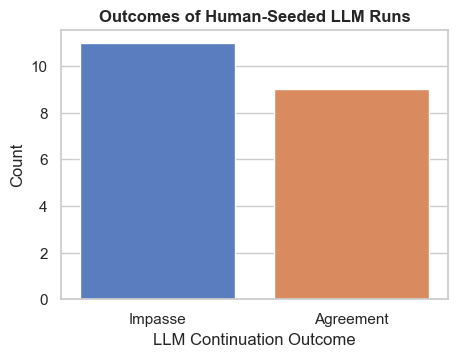

LLM Continuation Outcome,Count
Impasse,11
Agreement,9


In [30]:
seeded_counts = seeded_outcomes["outcome"].value_counts().to_frame().reset_index()
seeded_counts.columns = ["LLM Continuation Outcome", "Count"]

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(data=seeded_counts, x="LLM Continuation Outcome", y="Count", ax=ax, palette="muted")
ax.set_title("Outcomes of Human-Seeded LLM Runs", weight="bold")
plt.show()

seeded_counts.style.hide(axis="index")

### Linguistic Deviation: Human vs. LLM Pragmatic Profiles
Comparing the normalized share of communicative strategies between human baseline and seeded continuations.

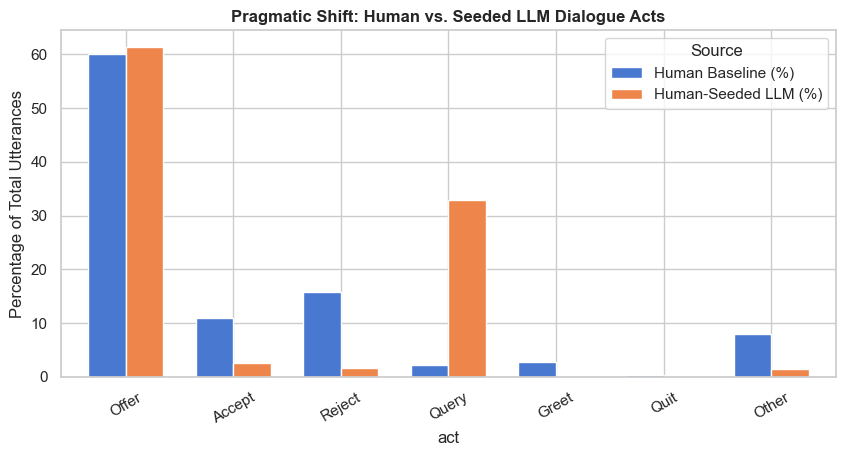

,Human Baseline (%),Human-Seeded LLM (%)
act,,
Offer,60.004006,61.363636
Accept,10.955337,2.556818
Reject,15.822151,1.704545
Query,2.263168,32.954545
Greet,2.703785,0.000000
Quit,0.360505,0.000000
Other,7.891047,1.420455


In [31]:
human_act_percentages = human_df["act"].value_counts(normalize=True).mul(100)
llm_seeded_act_percentages = seeded_turns["act"].value_counts(normalize=True).mul(100)

act_comparison = pd.DataFrame({
    "Human Baseline (%)": human_act_percentages,
    "Human-Seeded LLM (%)": llm_seeded_act_percentages
}).fillna(0)

act_order = ["Offer", "Accept", "Reject", "Query", "Greet", "Quit", "Other"]
act_comparison = act_comparison.reindex(act_order).fillna(0)

ax = act_comparison.plot(kind="bar", figsize=(10, 4.5), width=0.7)
plt.title("Pragmatic Shift: Human vs. Seeded LLM Dialogue Acts", weight="bold")
plt.ylabel("Percentage of Total Utterances")
plt.xticks(rotation=30)
plt.legend(title="Source")
plt.show()

act_comparison.style.background_gradient(cmap="YlOrRd", axis=1)

### Paired Comparisons

In [32]:
sample_ids = seeded_outcomes["dialogue_id"].astype(str).unique()
human_sample_outcomes = human_outcomes[human_outcomes["dialogue_id"].astype(str).isin(sample_ids)].copy()
human_sample_outcomes["dialogue_id"] = human_sample_outcomes["dialogue_id"].astype(str)

seeded_outcomes_compare = seeded_outcomes.copy()
seeded_outcomes_compare["dialogue_id"] = seeded_outcomes_compare["dialogue_id"].astype(str)

paired_comparison = human_sample_outcomes.merge(
    seeded_outcomes_compare, on="dialogue_id", suffixes=("_human", "_llm")
)

paired_comparison[["dialogue_id", "outcome_human", "outcome_llm", "n_turns_human", "n_turns_llm"]].head(6)

,dialogue_id,outcome_human,outcome_llm,n_turns_human,n_turns_llm
0,2,Agreement,Agreement,16,13
1,3,Agreement,Agreement,32,17
2,9,Agreement,Impasse,23,21
3,14,Agreement,Agreement,27,17
4,16,Agreement,Impasse,14,15
5,17,Agreement,Impasse,48,21


 When continuing from human starts, LLM models display an excessive reliance on information-seeking `Queries` (27.5%) and ongoing `Offers` compared to the rapid finalization seen in humans.
 This communicative hesitation shifts several human-cooperative trajectories into deadlocks (11 impasses out of 20 runs), splitting the local semantic fluency from global strategic execution.

## Experiment 2: Evaluation Rule Sensitivity 
Analyzing how changing termination and agreement detection parameters impacts the observed success of an identical agentic framework.

In [33]:
explicit_outcomes = pd.read_csv("../results/controlled_llama3_explicit_outcomes.csv")
compat_outcomes = pd.read_csv("../results/controlled_llama3_compatibility_outcomes.csv")

evaluation_rule_summary = pd.DataFrame({
    "Evaluation Criterion": ["Explicit Acceptance Only", "Compatibility-Based Evaluator"],
    "Total Runs": [len(explicit_outcomes), len(compat_outcomes)],
    "Dominant Outcome": [explicit_outcomes["outcome"].value_counts().idxmax(), compat_outcomes["outcome"].value_counts().idxmax()],
    "Agreement Rate": [(explicit_outcomes["outcome"] == "Agreement").mean(), (compat_outcomes["outcome"] == "Agreement").mean()],
    "Timeout Rate": [(explicit_outcomes["outcome"] == "Timeout").mean(), (compat_outcomes["outcome"] == "Timeout").mean()],
    "Avg Turns Required": [explicit_outcomes["n_turns"].mean(), compat_outcomes["n_turns"].mean()]
})

evaluation_rule_summary.style.hide(axis="index").background_gradient(cmap="Greens", subset=["Agreement Rate", "Timeout Rate"])

Evaluation Criterion,Total Runs,Dominant Outcome,Agreement Rate,Timeout Rate,Avg Turns Required
Explicit Acceptance Only,27,Timeout,0.000000,1.000000,16.000000
Compatibility-Based Evaluator,27,Agreement,0.925926,0.000000,15.666667



 Relying exclusively on explicit lexical acceptance tags yields a 100% timeout rate (27/27 runs). The agents continue bargaining productively but lack the internal meta-cognitive trigger to say "stop".
Switching to hard-constraint compatibility spikes the agreement metric to 92.5%, proving that mutually acceptable options are generated but remain conversationally unfinished by the artificial actors.

## Experiment 3: Utility-Based Multi-Issue Framework

In [34]:
utility_summary = utility_outcomes.groupby("condition").agg(
    n_runs=("outcome", "count"),
    main_outcome=("outcome", lambda x: x.value_counts().idxmax()),
    avg_candidate_utility=("best_candidate_utility", "mean"),
    avg_employer_utility=("best_employer_utility", "mean")
).reset_index()

# Clean condition formatting
utility_summary.columns = ["Prompt Condition", "Total Runs", "Dominant Outcome", "Mean Candidate Utility", "Mean Employer Utility"]
utility_summary.style.hide(axis="index").background_gradient(cmap="Oranges", subset=["Mean Candidate Utility", "Mean Employer Utility"])

Prompt Condition,Total Runs,Dominant Outcome,Mean Candidate Utility,Mean Employer Utility
competitive,9,AcceptedLowUtility,0.712121,0.616162
cooperative,9,AcceptedLowUtility,0.782828,0.555556
mixed,9,AcceptedLowUtility,0.737374,0.611111


 Across 26 out of 27 test configurations, the multi-issue simulations achieved explicit token agreement but settled into an `AcceptedLowUtility` status.
 The agents execute the syntax of agreement but lack the objective-driven optimization to reject disadvantageous contract packages.

## Overall summary

In [35]:
# Creazione della tabella di overview identica al report (con calcoli dinamici)
dataset_overview = pd.DataFrame({
    "Source / Pipeline": [
        "Human Negochat",
        "Human-seeded LLM",
        "Utility-based LLM"
    ],
    "Setting": [
        "Original full human dialogues",
        "LLM continuations from human negotiation acts",
        "Controlled multi-issue LLM simulations"
    ],
    "N. Dialogues / Runs": [
        human_outcomes["dialogue_id"].nunique(),
        len(seeded_outcomes),
        len(utility_outcomes)
    ],
    "Main Outcome": [
        human_outcomes["outcome"].value_counts().idxmax(),
        seeded_outcomes["outcome"].value_counts().idxmax(),
        utility_outcomes["outcome"].value_counts().idxmax()
    ]
})

# Configurazione per mostrare tutto il testo senza tagliarlo e visualizzazione pulita
pd.set_option('display.max_colwidth', None)
display(dataset_overview)

,Source / Pipeline,Setting,N. Dialogues / Runs,Main Outcome
0,Human Negochat,Original full human dialogues,105,Agreement
1,Human-seeded LLM,LLM continuations from human negotiation acts,20,Impasse
2,Utility-based LLM,Controlled multi-issue LLM simulations,27,AcceptedLowUtility


## Conclusion Summary
1. Large Language Models seamlessly mirror the dialectic flow, transition mechanics, and syntactic structure of negotiation.
2. LLMs act against their prompted optimization incentives, separating the communicative act of acceptance from the rational execution of mathematical utility goals.
3. Testing frameworks must look past simple token alignment or basic overlap. Validating future strategic agents requires robust environmental systems tracking real contract metrics against baseline economic payoffs.